# Macro Event Impact Tracker (Case Study)

Bu notebook, bir makroekonomik veri açıklanma anında (Örn: ABD TÜFE) piyasanın verdiği yüksek frekanslı tepkiyi analiz eder.

**Senaryo:** Beklentilerin üzerinde gelen TÜFE verisi sonrası SPY, DXY, US10Y ve VIX varlıklarının hareketi.

### Adım 1: Mock Data Üretimi
1 dakikalık frekansta, olay anında (15:30) şok etkisi içeren veriler oluşturuyoruz.

In [2]:
%pip install --upgrade --force-reinstall pandas numpy seaborn

import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

def generate_asset_path(start_price, shock_pct, drift, volatility, n_points, event_idx):
    prices = [start_price]
    for i in range(1, n_points):
        change = np.random.normal(drift, volatility)
        if i == event_idx:
            change += shock_pct
        new_price = prices[-1] * (1 + change)
        prices.append(new_price)
    return prices

event_time = datetime(2024, 5, 15, 15, 30)
start_time = event_time - timedelta(hours=1)
end_time = event_time + timedelta(hours=2)
timestamps = pd.date_range(start=start_time, end=end_time, freq='1min')
n_points = len(timestamps)
event_idx = list(timestamps).index(event_time)

np.random.seed(42)
data = {
    'Timestamp': timestamps,
    'SPY': generate_asset_path(520.0, -0.015, -0.0001, 0.0008, n_points, event_idx),
    'DXY': generate_asset_path(105.0, 0.008, 0.00005, 0.0004, n_points, event_idx),
    'US10Y': generate_asset_path(4.5, 0.02, 0.0001, 0.0015, n_points, event_idx),
    'VIX': generate_asset_path(14.0, 0.10, 0.0002, 0.005, n_points, event_idx)
}

df = pd.DataFrame(data)
print("Veri üretildi. İlk 5 satır:")
df.head()

  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-intel 2.18.0 requires numpy<2.1.0,>=1.26.0, but you have numpy 2.4.4 which is incompatible.


  Using cached pandas-3.0.2-cp312-cp312-win_amd64.whl.metadata (19 kB)
  Using cached numpy-2.4.4-cp312-cp312-win_amd64.whl.metadata (6.6 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl.metadata (8.4 kB)
  Using cached tzdata-2026.2-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached matplotlib-3.10.9-cp312-cp312-win_amd64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp312-cp312-win_amd64.whl.metadata (119 kB)
  Using cached kiwisolver-1.5.0-cp312-cp312-win_amd64.whl.metadata (5.2 kB)
  Using cached packaging-26.2-py3-none-any.whl.metadata (3.5 kB)
  Using cached pillow-12.2.0-cp312-cp312-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached six-1.17.0-py2.py3-none-any.whl.metadata (1.7 kB)
Using c

,Timestamp,SPY,DXY,US10Y,VIX
0,2024-05-15 14:30:00,520.000000,105.000000,4.500000,14.000000
1,2024-05-15 14:31:00,520.154633,105.031528,4.503956,14.061298
2,2024-05-15 14:32:00,520.045083,105.000768,4.514761,13.984685
3,2024-05-15 14:33:00,520.262540,104.961040,4.514476,14.024528
4,2024-05-15 14:34:00,520.844414,104.986545,4.517648,14.128419


### Adım 2: Normalizasyon
Fiyatları t=15:30 anında 100'e sabitliyoruz.

In [3]:
assets = ['SPY', 'DXY', 'US10Y', 'VIX']
event_ts = pd.Timestamp(event_time)

for asset in assets:
    base_price = df.loc[df['Timestamp'] == event_ts, asset].values[0]
    df[f'{asset}_idx'] = (df[asset] / base_price) * 100
    df[f'{asset}_pct'] = (df[asset] / base_price - 1) * 100

print("Normalizasyon tamamlandı.")

Normalizasyon tamamlandı.


### Adım 3: Görselleştirme
Piyasa tepkisini grafik üzerinde görelim.

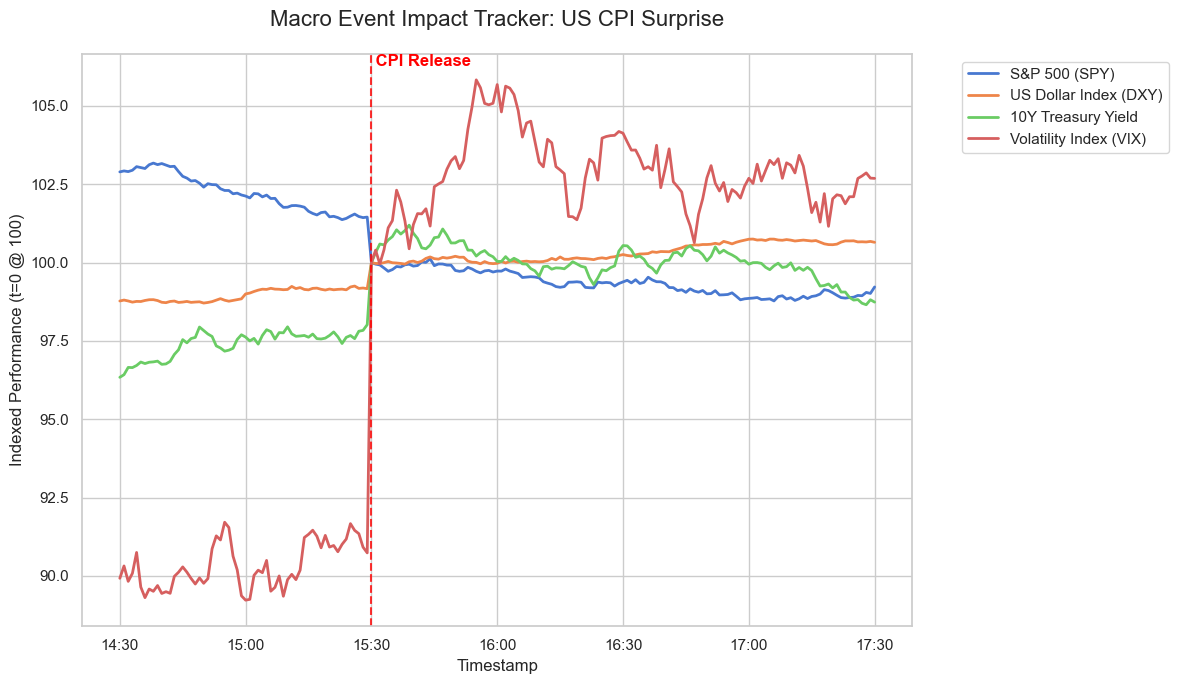

In [4]:
sns.set_theme(style="whitegrid", palette="muted")
plt.figure(figsize=(12, 7))

assets_map = {
    'SPY_idx': 'S&P 500 (SPY)',
    'DXY_idx': 'US Dollar Index (DXY)',
    'US10Y_idx': '10Y Treasury Yield',
    'VIX_idx': 'Volatility Index (VIX)'
}

for col, label in assets_map.items():
    sns.lineplot(data=df, x='Timestamp', y=col, label=label, linewidth=2)

plt.axvline(x=event_ts, color='red', linestyle='--', linewidth=1.5, alpha=0.8)
plt.text(event_ts, plt.ylim()[1], ' CPI Release', color='red', 
         verticalalignment='top', fontweight='bold', fontsize=12)

plt.title('Macro Event Impact Tracker: US CPI Surprise', fontsize=16, pad=20)
plt.ylabel('Indexed Performance (t=0 @ 100)')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Adım 4: Özet Tablo
15 ve 60 dakikalık net etkiler.

In [5]:
t_15 = event_ts + pd.Timedelta(minutes=15)
t_60 = event_ts + pd.Timedelta(minutes=60)

summary_data = []
for asset in assets:
    summary_data.append({
        'Asset': asset,
        '15-Min Impact (%)': round(df.loc[df['Timestamp'] == t_15, f'{asset}_pct'].values[0], 2),
        '60-Min Impact (%)': round(df.loc[df['Timestamp'] == t_60, f'{asset}_pct'].values[0], 2)
    })

summary_df = pd.DataFrame(summary_data)
summary_df

,Asset,15-Min Impact (%),60-Min Impact (%)
0,SPY,-0.10,-0.62
1,DXY,0.13,0.26
2,US10Y,0.80,0.54
3,VIX,2.42,4.13
